In [2]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import pickle
import os

In [3]:
# CARGO LOS DATOS
train = pd.read_csv("../data/processed/train_diabetes.csv")
test = pd.read_csv("../data/processed/test_diabetes.csv")

X_train = train.drop('Outcome', axis=1)
y_train = train['Outcome']

X_test = test.drop('Outcome', axis=1)
y_test = test['Outcome']

print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)

X_train.shape: (614, 8)
X_test.shape: (154, 8)


Los dos **hiperparámetros** principales que pide el enunciado son:
- n_estimators = Número de árboles en el bosque.
- max_depth = Profundidad máxima de cada árbol.

**Primer modelo Random Forest**

In [4]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



**Analizar el impacto de n_estimators y max_depth**

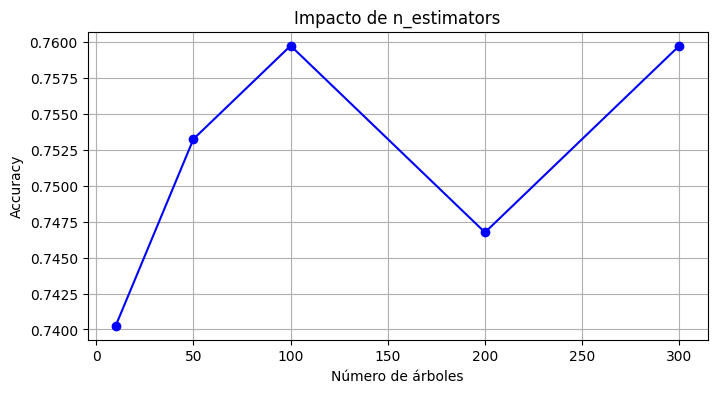

In [5]:
# Impacto de n_estimators
n_estimators = [10, 50, 100, 200, 300]
accuracy_estimators = []

for n in n_estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    accuracy_estimators.append(accuracy_score(y_test, model.predict(X_test)))

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(n_estimators, accuracy_estimators, marker='o', color='blue')
plt.title('Impacto de n_estimators')
plt.xlabel('Número de árboles')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

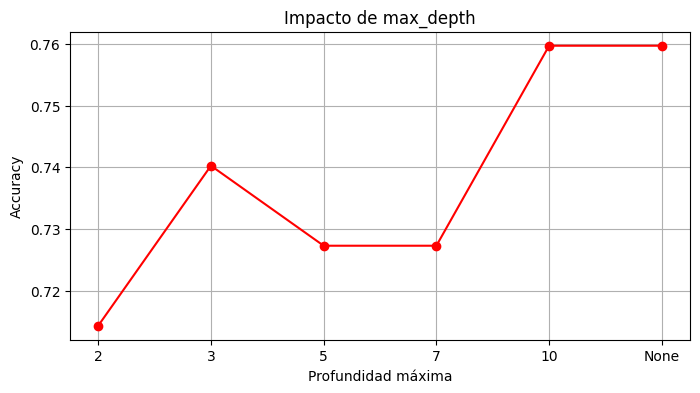

In [6]:
# Impacto DE max_depth
max_depth = [2, 3, 5, 7, 10, None]
accuracy_depth = []

for i in max_depth:
    model = RandomForestClassifier(max_depth=i, n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    accuracy_depth.append(accuracy_score(y_test, model.predict(X_test)))

# Graficar
labels = [str(i) for i in max_depth]
plt.figure(figsize=(8, 4))
plt.plot(labels, accuracy_depth, marker='o', color='red')
plt.title('Impacto de max_depth')
plt.xlabel('Profundidad máxima')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

**Optimizar con GridSearchCV**

In [7]:
config_data = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=config_data,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor accuracy CV:", grid_rf.best_score_)

mejor_rf = grid_rf.best_estimator_
y_pred_final = mejor_rf.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Mejores parámetros: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Mejor accuracy CV: 0.7817939490870318
Accuracy en test: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



**Árbol de decisión vs. Random Forest**

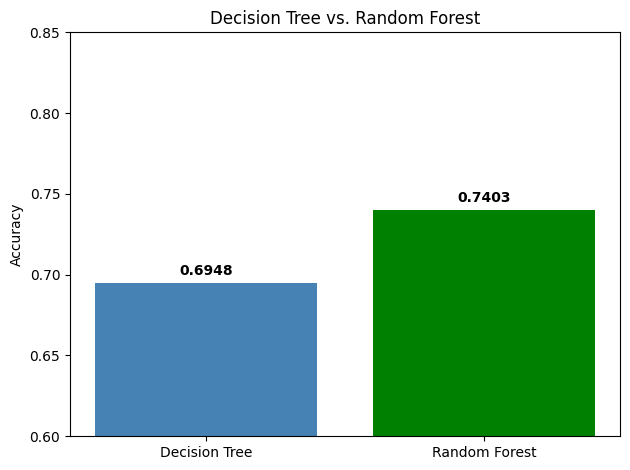

In [8]:
resultados = {
    'Decision Tree': 0.6948, # Mi resultado anterior en el Decision Tree optimizado
    'Random Forest': accuracy_score(y_test, y_pred_final)
}

plt.bar(resultados.keys(), resultados.values(), color=['steelblue', 'green'])
plt.title('Decision Tree vs. Random Forest')
plt.ylabel('Accuracy')
plt.ylim(0.60, 0.85)
for i, (k, v) in enumerate(resultados.items()):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Importancia de cada variable en el Random Forest**

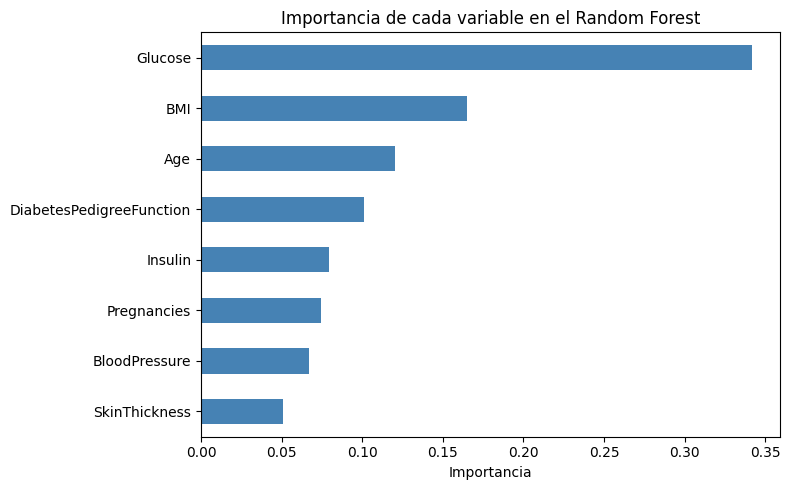

In [9]:
importances = pd.Series(mejor_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='steelblue', figsize=(8, 5))
plt.title('Importancia de cada variable en el Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

- La variable más importante para el Random Forest es Glucose, seguida de BMI y Age, lo que concuerda con la matriz de correlación del EDA.

**Guardar modelo**

In [10]:
os.makedirs("../models", exist_ok=True)

with open("../models/random_forest_diabetes.pkl", "wb") as f:
    pickle.dump(mejor_rf, f)

print("Modelo guardado")

Modelo guardado
